# <span style="color:purple; font-weight:bold; text-decoration:underline;"> East Asian SO2 Emissions: CEDS 

### <span style="color:purple;"> Uploading SO2 emissions by country: CEDS

In [1]:
import pandas as pd

# Open CEDS SO2 emissions by country sector 
file_path = 'SO2_CEDS_emissions_by_country_sector_v2024_04_01.csv'
df = pd.read_csv(file_path)

# Rename year columns: strip 'X' and convert to int
def rename_col(c):
    if c.startswith('X'):
        return int(c[1:])
    else:
        return c

df = df.rename(columns=rename_col)

### <span style="color:purple;"> Parsing Emissions from East Asia: China, Japan, and South Korea 

In [2]:
def get_country_df(df, country_code):
    # Step 1: Filter for country
    country_df = df[df["country"] == country_code].reset_index(drop=True)
    
    # Step 2: Keep only the year columns
    year_cols = ['sector'] + [c for c in df.columns if isinstance(c, int) and 1850 <= c <= 2015]
    country_df = country_df[year_cols]
    
    return country_df

df_china        = get_country_df(df, "chn")
df_japan        = get_country_df(df, "jpn")
df_south_korea  = get_country_df(df, "kor")

### <span style="color:purple;"> Country & Region Totaling

In [3]:
china_totals = df_china.sum(axis=0, numeric_only=True)
japan_totals = df_japan.sum(axis=0, numeric_only=True)
skorea_totals = df_south_korea.sum(axis=0, numeric_only=True)
east_asia_totals = china_totals + japan_totals + skorea_totals

### <span style="color:purple;"> Plotting Country & Region Timeseries

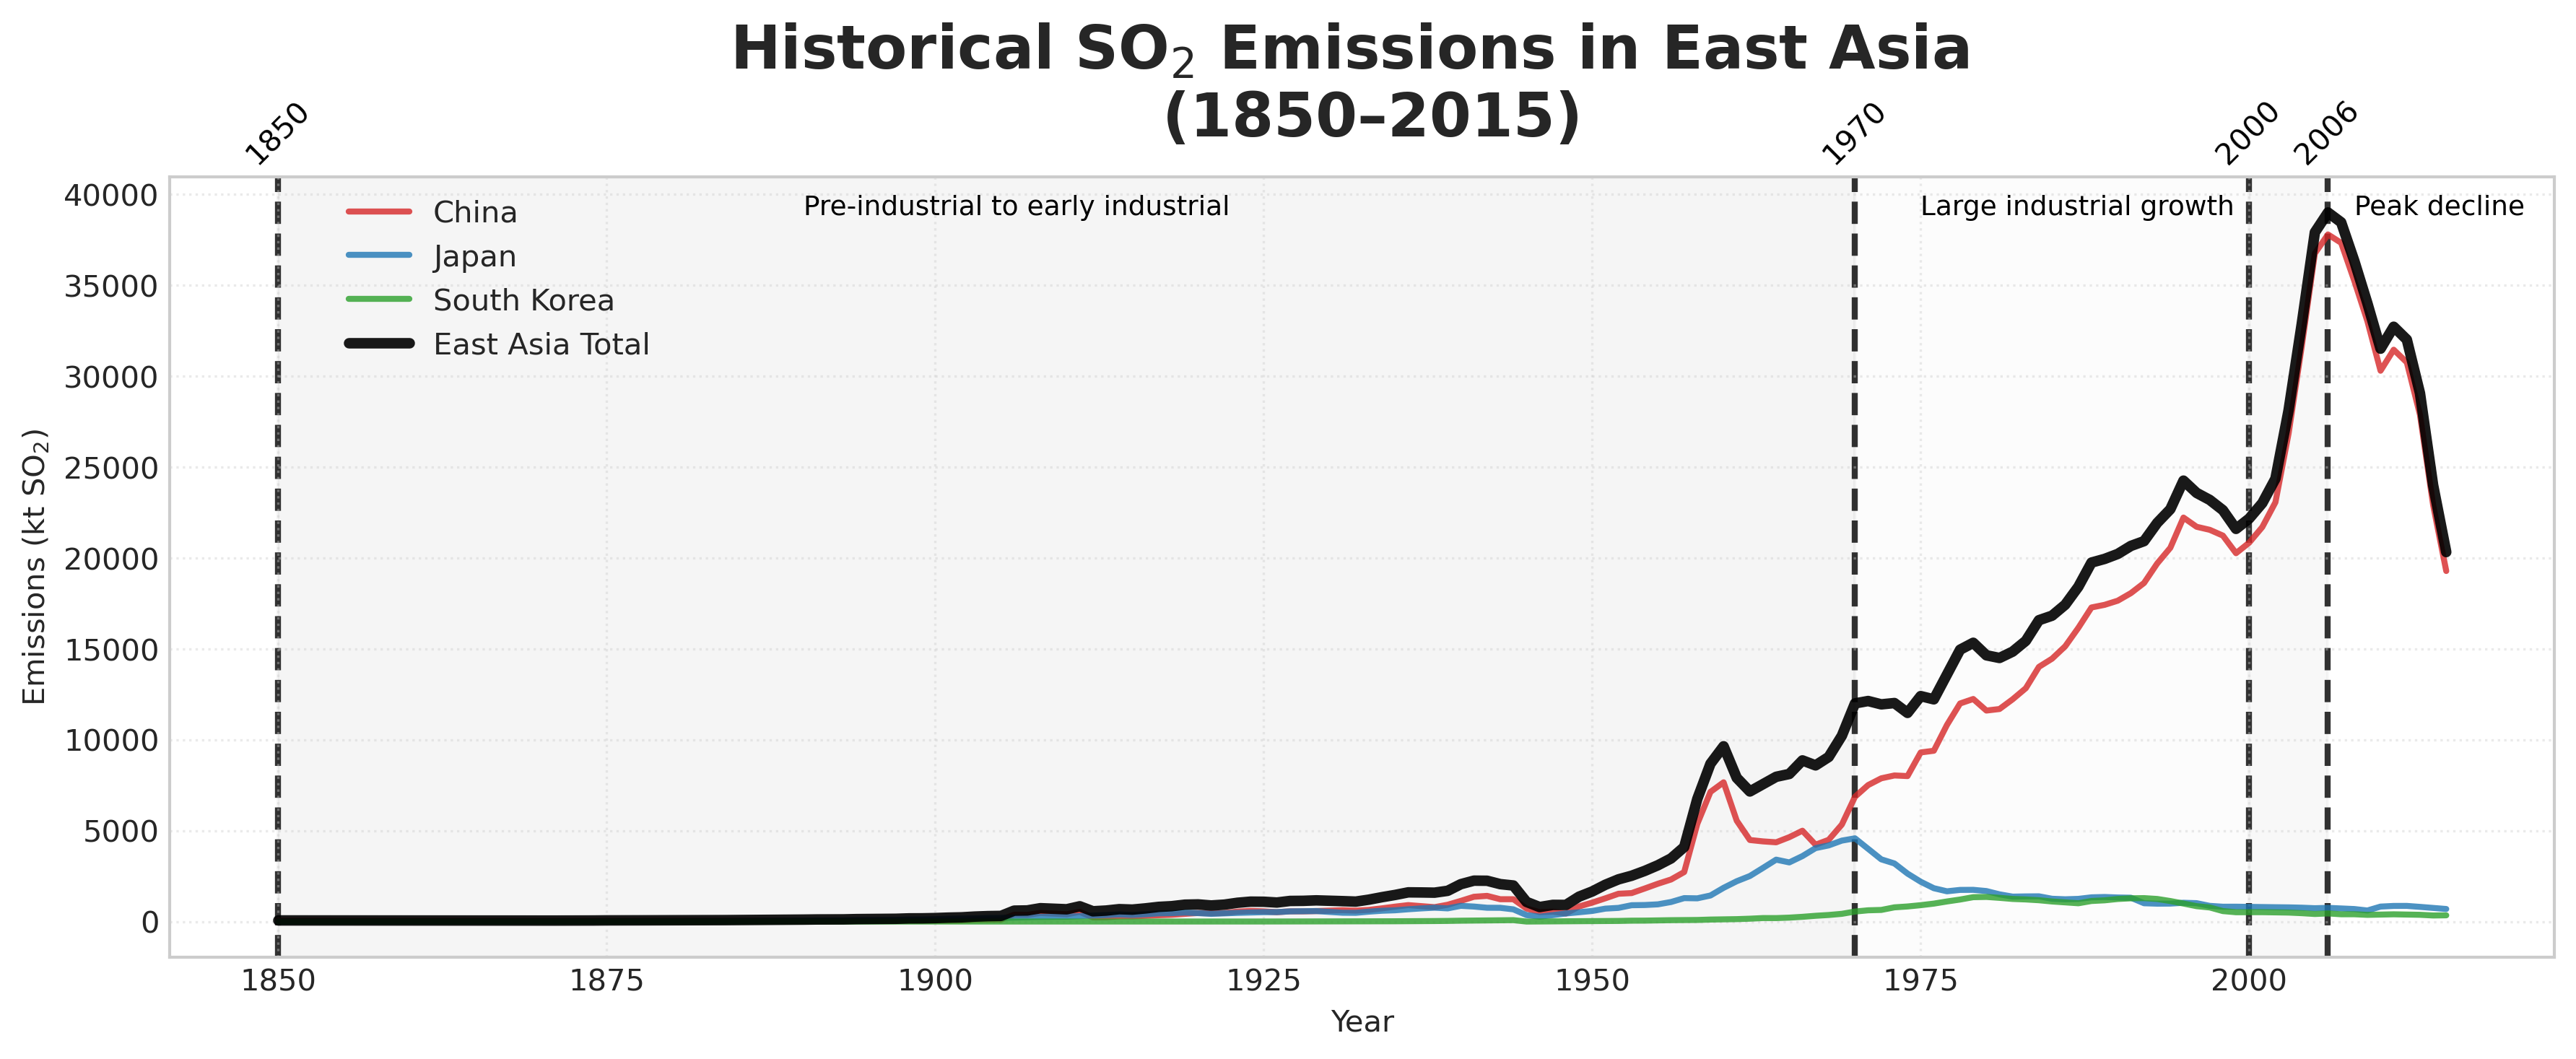

In [4]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'legend.frameon': False, 'lines.linewidth': 2})

highlight_years = [1850, 1970, 2000, 2006]

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

# Plot lines
ax.plot(china_totals.index, china_totals, label='China', color='#d62728', alpha=0.8)
ax.plot(japan_totals.index, japan_totals, label='Japan', color='#1f77b4', alpha=0.8)
ax.plot(skorea_totals.index, skorea_totals, label='South Korea', color='#2ca02c', alpha=0.8)
ax.plot(east_asia_totals.index, east_asia_totals, label='East Asia Total',
        color='black', linewidth=3.5, alpha=0.9, zorder=6)

# Get top of y-limits
ymax = ax.get_ylim()[1]

# Example: lightly shaded eras
ax.axvspan(1850, 1970, color='gray', alpha=0.08, zorder=0)
ax.axvspan(1970, 2000, color='lightgray', alpha=0.05, zorder=0)
ax.axvspan(2000, 2006, color='gray', alpha=0.05, zorder=0)
ax.text(1890, ymax * 0.95, "Pre-industrial to early industrial", fontsize=9, color='black')
ax.text(1975, ymax * 0.95, "Large industrial growth", fontsize=9, color='black')
ax.text(2008, ymax * 0.95, "Peak decline", fontsize=9, color='black')

# Highlight years (single set of lines)
# Add highlight lines and top-aligned labels
for year in highlight_years:
    ax.axvline(x=year, color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=0)

# Get top of y-limits
ymax = ax.get_ylim()[1]

for year in highlight_years:
    ax.text(year, ymax * 1.01, str(year),  # 1.01 = 1% above top of axis
            fontsize=10, color='black', ha='center', va='bottom', rotation=45)

# Labels and legend
ax.set_title('Historical SO$_{2}$ Emissions in East Asia  \n (1850–2015)', fontsize=20, weight='bold', y=1.03)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (kt SO$_{2}$)')
ax.legend(loc=(0.07, 0.75))
ax.grid(True, linestyle=':', alpha=0.4)

#ax.set_xlim(1849, 2020)
plt.tight_layout()
plt.show()